# **A/B тест на основе [датасета](https://www.kaggle.com/datasets/sergylog/ab-test-data)**

**Постановка задачи:** <br>
Сайт запустил A/B-тест с целью увеличения дохода. Файл 'AB_Test_Results.csv' содержит исходные данные о результатах эксперимента (user_id), типе выборки (variant_name) и доходе, который принес пользователь (revenue). <br>
Задача состоит в том, чтобы проанализировать результаты эксперимента и написать свои рекомендации.

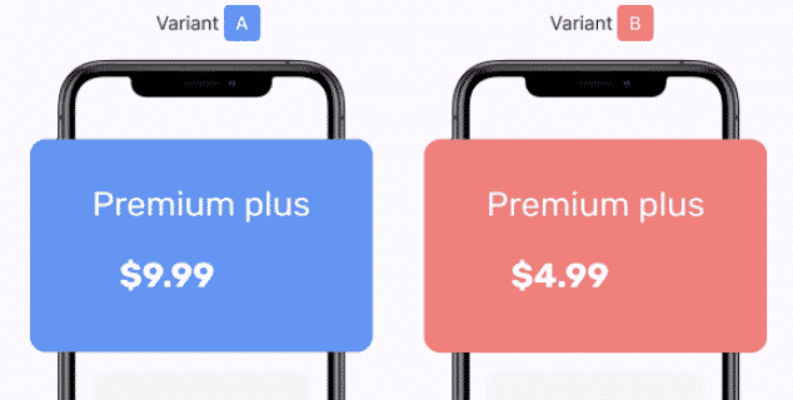

## Подготовка данных

Импортируем необходимые библиотеки:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

Считываем таблицу в датафрейм и выводим ее размер

In [2]:
df = pd.read_csv("AB_Test_Results.csv")
print(df.head(5))
print(df.shape)

   USER_ID VARIANT_NAME  REVENUE
0      737      variant      0.0
1     2423      control      0.0
2     9411      control      0.0
3     7311      control      0.0
4     6174      variant      0.0
(10000, 3)


Проверяем, есть ли пустые значения

In [3]:
df[df.isnull().any(axis=1)].shape[0]

0

Пустых значений нет. Переводим все значения прибыли в тип вещественных чисел

In [4]:
pd.to_numeric(df["REVENUE"], errors='coerce')
df[df["REVENUE"] != 0.0].head(5)

,USER_ID,VARIANT_NAME,REVENUE
13,2529,variant,2.15
49,6429,control,3.25
139,3331,variant,4.27
149,8110,variant,1.75
152,8607,control,2.99


Проверяем дубликаты

In [5]:
print(df["USER_ID"].unique().shape[0])
print(df["VARIANT_NAME"].unique())

6324
['variant' 'control']


Различных значений USER_ID 6324, а всего значений 10000. Т.е. некоторые USER_ID повторяются. Просуммируем REVENUE для всех одинаковых пар (USER_ID, VARIANT_NAME).

In [6]:
agg_fnc = {"REVENUE": "sum"}
unique_df = df.groupby(["USER_ID", "VARIANT_NAME"]).agg(agg_fnc).reset_index()
print(unique_df.shape)

(7865, 3)


Удалим покупки пользователей, которые имели доступ к обоим выборкам.

In [7]:
separate_category_users = unique_df[~unique_df['USER_ID'].isin(
    set(unique_df[unique_df['VARIANT_NAME'] == 'variant']['USER_ID']) &
    set(unique_df[unique_df['VARIANT_NAME'] == 'control']['USER_ID'])
)]
separate_category_users.shape[0]

4783

Наконец, разделим по контрольной и экспериментальной выборкам.

In [8]:
u_variant = separate_category_users[separate_category_users["VARIANT_NAME"] == "variant"]
u_control = separate_category_users[separate_category_users["VARIANT_NAME"] == "control"]
print(f"Размер эксп. выборки: {u_variant.shape[0]}, контр. выборки: {u_control.shape[0]}")

Размер эксп. выборки: 2393, контр. выборки: 2390


Проверяем выбросы

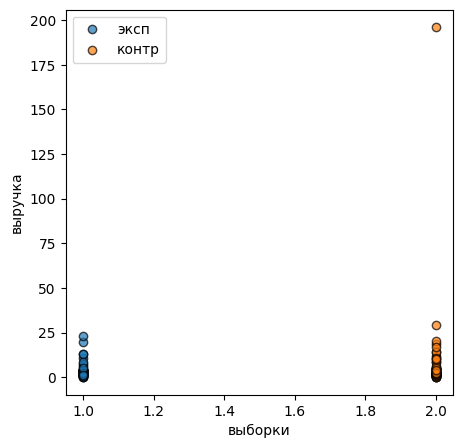

In [9]:
not_null_rev = separate_category_users[separate_category_users["REVENUE"] != 0.0]
not_null_rev_v = u_variant[u_variant["REVENUE"] != 0.0]
not_null_rev_c = u_control[u_control["REVENUE"] != 0.0]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(np.ones(not_null_rev_v.shape[0]), not_null_rev_v["REVENUE"], label='эксп', alpha=0.7, edgecolors='black')
ax.scatter(2 * np.ones(not_null_rev_c.shape[0]), not_null_rev_c["REVENUE"], label='контр', alpha=0.7, edgecolors='black')
plt.xlabel('выборки')
plt.ylabel('выручка')
plt.legend()
plt.show()

In [10]:
not_null_rev_c.sort_values(by="REVENUE").tail(5)

,USER_ID,VARIANT_NAME,REVENUE
3516,4445,control,17.05
211,282,control,18.56
830,1053,control,20.07
1722,2166,control,29.32
2663,3342,control,196.01


In [11]:
Q1, Q3 = not_null_rev["REVENUE"].quantile([0.25, 0.75])
IQR = Q3 - Q1
low = Q1 - 5 * IQR
up = Q3 + 5 * IQR
u_control = u_control[u_control["REVENUE"] <= up]
u_variant = u_variant[u_variant["REVENUE"] <= up]

In [12]:
print(u_control.sort_values(by="REVENUE").tail(1))
print(u_variant.sort_values(by="REVENUE").tail(1))

     USER_ID VARIANT_NAME  REVENUE
830     1053      control    20.07
      USER_ID VARIANT_NAME  REVENUE
5791     7356      variant    23.04


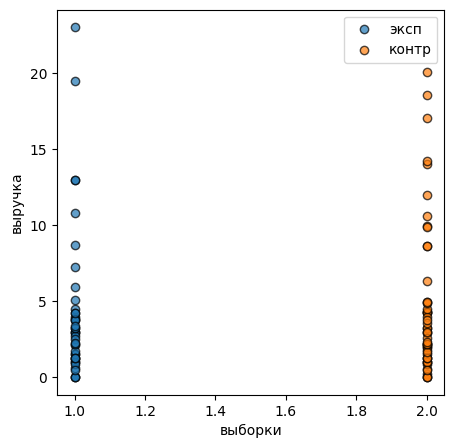

In [13]:
not_null_rev_v = u_variant[u_variant["REVENUE"] != 0.0]
not_null_rev_c = u_control[u_control["REVENUE"] != 0.0]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(np.ones(not_null_rev_v.shape[0]), not_null_rev_v["REVENUE"], label='эксп', alpha=0.7, edgecolors='black')
ax.scatter(2 * np.ones(not_null_rev_c.shape[0]), not_null_rev_c["REVENUE"], label='контр', alpha=0.7, edgecolors='black')
plt.xlabel('выборки')
plt.ylabel('выручка')
plt.legend()
plt.show()

Проверяем SRM:

In [14]:
v_size = u_variant.shape[0]
c_size = u_control.shape[0]
print(f"Размер эксп. выборки: {v_size} ({round(100 * v_size / (v_size + c_size))}%), контр. выборки: {c_size} ({round(100 * c_size / (v_size + c_size))}%)")

Размер эксп. выборки: 2393 (50%), контр. выборки: 2388 (50%)


## Анализ данных

Гипотеза заключается в том, что если мы применим данное изменение, то среднее значение выручки возрастет. <br>
$$ H_0: ARPU_{control} =  ARPU_{variant}$$
$$ H_1: ARPU_{control} \ne  ARPU_{variant}$$

Primary метрика: REVENUE per user (средняя выручка на пользователя) <br>
[тип метрики: непрерывная]<br>
Guardrails: конверсия - доля ненулевых значений REVENUE

In [17]:
ARPU_control = u_control["REVENUE"].mean()
ARPU_variant = u_variant["REVENUE"].mean()
print(f'ARPU_variant = {ARPU_variant:.3f}, ARPU_control = {ARPU_control:.3f}')

ARPU_variant = 0.075, ARPU_control = 0.103


In [26]:
guardrails_c = u_control[u_control["REVENUE"] != 0.0].shape[0] / c_size
guardrails_v = u_variant[u_variant["REVENUE"] != 0.0].shape[0] / v_size
print(f'Доля ненулевых значений REVENUE в эксп. выборке: {round(100*guardrails_v, 1)} %, контр. выборке: {round(100*guardrails_c, 1)} %')

Доля ненулевых значений REVENUE в эксп. выборке: 1.8 %, контр. выборке: 2.2 %


Для revenue-метрики рекомендуется применить Welch t-test или bootstrap, потому что revenue часто имеет скошенное распределение и выбросы.

Задаем уровень значимости α = 0.05

In [18]:
alpha = 0.05

In [50]:
np.random.seed(42)

mean_diff = ARPU_variant - ARPU_control

bootstrap_means = []
combined_revenue = np.concat([u_control["REVENUE"], u_variant["REVENUE"]])
combined_size = combined_revenue.shape[0]
for _ in range(1000):
  a_idx = set(np.random.choice(range(combined_size), size=v_size, replace=False))
  b_idx = set(range(combined_size)) - a_idx
  bootstrap_means.append(combined_revenue[list(a_idx)].mean() - combined_revenue[list(b_idx)].mean())

p_value = 0
for i in bootstrap_means:
  if abs(i) >= abs(mean_diff):
    p_value += 1
p_value = p_value / len(bootstrap_means)

conf_interval_pct = 0.95
conf_int_l = (1 - conf_interval_pct) / 2
conf_int_u = conf_interval_pct + conf_int_l
conf_interval = np.percentile(bootstrap_means, [conf_int_l * 100, conf_int_u * 100])

print(f'Полученная разница ARPU: {mean_diff:.3f}.')
print(f'p-value (двустороннее): {p_value:.3f} ', end='')
if p_value <= alpha:
  print('<= alpha. Тест статистически значим.')
else:
  print('> alpha. Тест не статистически значим.')
print(f'{round(conf_interval_pct * 100)}% доверительный интервал: [{conf_interval[0]:.3f}, {conf_interval[1]:.3f}]')

Полученная разница ARPU: -0.028.
p-value (двустороннее): 0.305 > alpha. Тест не статистически значим.
95% доверительный интервал: [-0.051, 0.050]


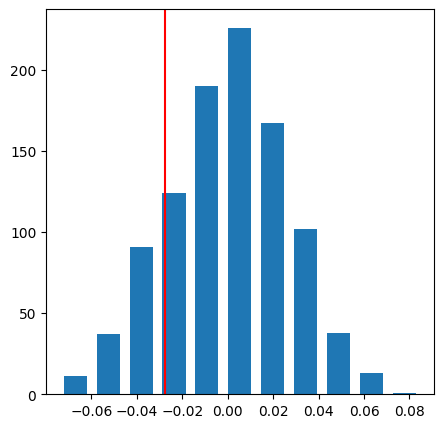

In [51]:
fig, ax = plt.subplots(figsize=(5,5))
ax.hist(bootstrap_means, bins=11, rwidth=0.7)
ax.axvline(x=mean_diff, c='red')
plt.show()

Тест не статистически значимый.

**Вывод**: <br>
Рекомендуется **не внедрять** изменение. <br>

*   Тест оказался **не** стат. значимым;
*   Primary метрика (ARPU) на экспериментальной выборке показала себя на 0.028 **хуже**, чем на контрольной;
*   Guardrails метрика (конверсия) - доля приносящих доход пользователей **уменьшилась** на 0.4%.

